Simple Hierarchical Multi-Agent System with Ollama
===============================================
Shows how to organize agents in teams with team leaders.

Structure:
- CEO (top level)
  - Research Team Leader
    - Data Researcher
    - Market Researcher
  - Writing Team Leader
    - Technical Writer
    - Summary Writer

In [1]:
import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver
from langchain.chat_models import init_chat_model
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from typing import TypedDict, Annotated, List, Literal, Dict, Any
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
import random
from datetime import datetime
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool
from langchain_tavily import TavilySearch

C:\Users\abhif\AppData\Local\Temp\ipykernel_260748\2482002610.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
llm = ChatOllama(
      model="gpt-oss:latest",
      temperature=0.7
  )

In [4]:
#==================================
#  State Definition ===============
#==================================
class CEOState(MessagesState):
    """State for the Hirarchical Multi Agent System"""
    next_agent:str
    data_research: str
    market_research: str
    final_research: str
    technical_report:str
    summary_report:str
    final_report:str
    current_task:str

    

### CEO Chain

In [5]:
# ===================================
# CEO with OLLAMA LLM
# ===================================
def create_ceo_chain():
    "Create the CEO with decision chain"
    ceo_prompt = ChatPromptTemplate.from_messages([
        ("system", """"You are the CEO managing team of agents:
        1. Researcher - Gather the market research informaton and data
        2. Writer - Creates reports and summaries

        Based on the current state and conversation, decide which agent should work next.
        If the task is complete, respone with 'DONE'

        Current State:
        - Has research data: {has_research}
        - Has report: {has_report}

        Respond with only the agent name (researcher/writer) or 'DONE'.
        """),
        ("human", "{task}")
    ])

    return ceo_prompt | llm

### CEO Agent

In [6]:
# ===================================
# Agent 1: CEO (using OLLAMA)
# ===================================
def ceo_agent(state:CEOState) -> Dict:
    """CEO decides next agent using Ollama LLM"""
    messages = state["messages"]
    task = messages[-1].content if messages else "No task"

    # Check what has been done
    has_research = bool(state.get("final_research", ""))
    has_report = bool(state.get("final_report", ""))

    # Get LLM decision
    chain = create_ceo_chain()
    decision = chain.invoke({
        "task": task,
        "has_research": has_research,
        "has_report": has_report
    })

    decision_text = decision.content.strip().lower()
    print(decision_text)

    # Determine the next agent
    if "done" in decision_text or has_report:
        next_agent = "end"
        ceo_msg = "CEO: All task complete! Great work team"
    elif "researcher" in decision_text or not has_research:
        next_agent = "researcher"
        ceo_msg = "📋 CEO: Let's start with research. Assigning to Researcher..."
    elif "writer" in decision_text or (has_research and not has_report):
        next_agent = "writer"
        ceo_msg = "📋 CEO: Let's start with writing. Assigning to Writer..."
    else:
        next_agent = "end"
        ceo_msg = "📋 CEO: Task seems complete."

    return {
        "messages": [AIMessage(content=ceo_msg)],
        "next_agent": next_agent,
        "current_task": task
    }

# Web Search Tool

In [7]:
tavily_search = TavilySearch(
    max_results=5
)

tools = [tavily_search]
researcher_llm = llm.bind_tools(tools)

#### Researcher Chain

In [8]:
#===========================
# Research with Ollama
#==========================
def create_researcher_chain():
    """Creates a Researcher with decision chain"""
    researcher_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a researcher managing a team of agents:
        1. Data Researcher 
            - Searches, gathers, and analyzes factual data.
            - Focuses on structured and technical data.

        2. Market Researcher 
            - Researches market-related information.
            - Analyzes market trends, competitors, industry developments, customer behavior, and other relevant market insights.
            - Focuses on external and business-oriented information.


        Based on the current state of conversation, decide which agent should work next.
        If the both research has been done, respond with 'DONE'.
        Cureent State:
        - Has factual and technical data: {has_fact_tech_research}
        - Has marke-related informaton: {has_market_research}

        Respond with ONLY the agent name (data_researcher/market_researcher) or DONE.
        """),
        ("human", "{task}")
    ])

    return researcher_prompt | llm

In [9]:
from langgraph.prebuilt import ToolRuntime
@tool
def generate_the_research_report(query: str)->str:
    """
    Generate a comprehensive research report based on the user's query.

    Analyze the provided research information carefully and produce a
    structured, factual, and easy-to-understand report.

    The report should:

    - Directly address the user's research question.
    - Organize the findings into logical sections.
    - Highlight the most important findings and insights.
    - Use tables or bullet points when they improve readability.
    - Clearly distinguish facts, observations, and recommendations.
    - Avoid unnecessary repetition or unsupported assumptions.
    - Provide a concise conclusion summarizing the key findings.

    Return only the final research report suitable for presentation to
    the user.

    User Research Query:
    """
    response = researcher_llm.invoke(query)  #  llm.invoke([HumanMessage(content=query)])
    print(response)
    return response.content

#### Researcher Head Agent

In [10]:
# =======================================
# Agent 2: Researcher Head (using OLLAMA)
# =======================================
def researcher_head_agent(state:CEOState) -> Dict:
    "Researcher uses Ollama to gather information"
    task = state.get("current_task", "Research Topic")

    # Check what's has been done
    has_fact_tech_research = bool(state.get("data_research", ""))
    has_market_research = bool(state.get("market_research", ""))

    # Get llm decision
    chain = create_researcher_chain()
    decision = chain.invoke({
        "task": task,
        "has_fact_tech_research":has_fact_tech_research,
        "has_market_research": has_market_research
    })
    # Parse decision
    decision_text = decision.content.strip().lower()
    print(decision_text)
    data_research = state.get("data_research", "")
    market_research = state.get("market_research", "")
    final_research = state.get("final_research", "")
    # Determine the next agent
    if "done" in decision_text:
        query = f"Generate the final combined report from {data_research} and {market_research}"
        final_research = generate_the_research_report.invoke({"query":query})
        agent_message = f"🔍 Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{final_research[:500]}..."
        next_agent = "ceo"
    elif "data_researcher" in decision_text or not has_fact_tech_research:
        next_agent = "data_researcher"
        researcher_msg = "Let's Searches, gathers, and analyzes factual data"
        agent_message = f"🔍 Researcher: calling data_researcher_agent..."
    elif "has_market_research" in decision_text or (has_fact_tech_research and not has_market_research):
        next_agent = "market_researcher"
        researcher_msg = "Let's Searches, gathers, and analyzes factual data"
        agent_message = f"🔍 Researcher: calling market_researcher_agent..."
    else:
        query = f"Generate the final combined report from {data_research} and {market_research}"
        final_research = generate_the_research_report.invoke({"query":query})
        agent_message = f"🔍 Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{final_research[:500]}..."
        next_agent = "ceo"
    return {
        "messages": [AIMessage(content=agent_message)],
        "current_task": task,
        "final_research":final_research,
        "data_research": data_research,
        "market_research": market_research,
        "next_agent": next_agent
    }

#### Data Researcher Agent

In [11]:
# =======================================
# Agent 3: data_researcher_agent
# =======================================
def data_researcher_agent(state:CEOState)->Dict:
    """Data Researcher uses Ollama to gather information"""
    task = state.get("current_task", "research topic")
    # Create research prompt
    data_research_prompt = f"""
        You are a Data Research Specialist.

        Your responsibility is to collect, analyze, and summarize
        relevant factual and data-driven information about the
        following research task:

        {task}

        Focus specifically on:

        1. Key facts and background information
        2. Important statistics, metrics, and quantitative data
        3. Relevant technical or structured information
        4. Historical data or comparisons when relevant
        5. Notable examples, datasets, or case studies
        6. Data-supported findings and observations

        Requirements:

        - Focus on factual and verifiable information.
        - Prioritize accurate and relevant data over general opinions.
        - Do not make unsupported assumptions or invent statistics.
        - Clearly distinguish known facts from interpretations.
        - Keep the response concise but sufficiently detailed.
        - Organize the findings using headings, bullet points, or
        tables when appropriate.

        Return the research findings only. Do not provide a final
        recommendation unless explicitly requested.
        """
    # Get research from LLM
    research_response = llm.invoke([HumanMessage(content=data_research_prompt)])
    data_research = research_response.content
    
    # Create agent message
    agent_message = f"🔍 Researcher: I've completed the data research on '{task}'.\n\nKey findings:\n{data_research[:500]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "data_research": data_research,
        "next_agent": "researcher_head_agent"
    }


    

#### Market Researcher Agent

In [12]:
#==================================
## Agent 4: market_researcher agent
#==================================
def market_researcher_agent(state:CEOState)->Dict:
    """Data Researcher uses Ollama to gather information"""
    task = state.get("current_task", "research topic")
    # Create research prompt
    market_research_prompt = f"""
You are a Market Research Specialist.

Your responsibility is to research and analyze market-related
information relevant to the following research task:

{task}

Focus specifically on:

1. Current market trends and developments
2. Industry landscape and growth patterns
3. Key market players and competitors
4. Competitive positioning and differentiators
5. Customer needs, behavior, and market demand
6. Emerging technologies, opportunities, and challenges
7. Relevant market statistics, reports, and forecasts
8. Notable companies, products, or real-world examples

Requirements:

- Focus on current and relevant market information.
- Prioritize factual and evidence-based market insights.
- Clearly identify important trends and their potential impact.
- Compare competitors or market players when relevant.
- Do not invent market statistics, companies, or trends.
- Clearly distinguish facts from analysis or interpretation.
- Avoid duplicating purely technical or internal data that belongs
  to the Data Researcher.
- Keep the response concise but sufficiently detailed.
- Organize findings using headings, bullet points, or tables
  when appropriate.

Return the market research findings only. Do not provide a final
recommendation unless explicitly requested.
"""

    # Get research from LLM
    research_response = llm.invoke([HumanMessage(content=market_research_prompt)])
    market_research = research_response.content
    
    # Create agent message
    agent_message = f"🔍 Researcher: I've completed the data research on '{task}'.\n\nKey findings:\n{market_research[:500]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "market_research": market_research,
        "next_agent": "researcher_head_agent"
    }

#### Financial Technical Writer Tool

In [13]:
from langgraph.prebuilt import ToolRuntime

@tool
def write_the_final_technical_report(query: str) -> str:
    """
    You are a Senior Technical Research Analyst responsible for
    preparing the final technical research report.

    The input contains the original research question along with
    findings collected by specialized research agents.

    Your responsibility is to analyze, synthesize, and present these
    findings as one clear, accurate, and professional technical report.

    Follow these guidelines:

    1. Understand the original research question and ensure the report
       directly addresses it.

    2. Synthesize relevant findings from the Data Researcher and
       Market Researcher without unnecessarily repeating information.

    3. Present important technical facts, statistics, trends,
       comparisons, and findings in a logical structure.

    4. Clearly distinguish between:
       - Facts and data
       - Research findings
       - Analysis or interpretation
       - Recommendations

    5. Use appropriate formatting such as:
       - Headings and subheadings
       - Bullet points
       - Tables
       - Numbered lists

       Use tables when they make comparisons or structured information
       easier to understand.

    6. Do not invent information, statistics, sources, or conclusions.
       Base the report only on the information provided by the research
       agents and the original query.

    7. Resolve conflicting findings carefully. If the available
       information is insufficient to determine which finding is
       correct, explicitly mention the uncertainty.

    8. Focus on actionable and technically relevant insights while
       avoiding unnecessary general information.

    9. Provide recommendations only when they are supported by the
       research findings.

    10. End the report with a concise Summary or Conclusion highlighting
        the most important findings.

    The final response must be:
    - Professional
    - Factual
    - Well structured
    - Concise but sufficiently detailed
    - Suitable for presentation to a technical or business audience

    Return only the final technical research report.

    Research Query and Findings:
    """
    
    response = llm.invoke(query)

    print(response)

    return response.content

#### Technical Writer Chain

In [14]:
#===========================
# Technical writing with Ollama
#==========================
def create_technical_writer_chain():
    """Creates a Technical writer with decision chain"""
    tech_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a technical writer a team of agents:
        1. Technical Reporter
            - Your task is to analyze the technical and factual research data
                provided by the research team and produce clear, structured,
                and meaningful technical findings.
            - Focus on technical details, data, statistics, metrics,
                comparisons, patterns, and key technical insights.

        2. Summary Reporter
            - Your task is to summarize the research findings provided by
                the research team into a clear, concise, and meaningful summary.
            - Focus on the most important findings, trends, insights,
                conclusions, and overall takeaways.


        Based on the current state of conversation, decide which agent should work next.
        If the both research has been done, respond with 'DONE'.
        Cureent State:
        - Has factual and technical data: {has_technical_report}
        - Has marke-related informaton: {has_summary_report}

        Respond with ONLY the agent name (technical_data_writer/summary_writer) or DONE.
        """),
        ("human", "{task}")
    ])

    return tech_prompt | llm

In [15]:
#================================
## Agent 5: Technical Writer Head
#================================
def writer_head_agent(state:CEOState) -> Dict:
    "Writer Head uses ollama to gather information"
    task = state.get("current_task", "Research Topic")

    # Check what's has been done
    has_technical_report = bool(state.get("technical_report", ""))
    has_summary_report = bool(state.get("summary_report", ""))
    # Get llm decision
    chain = create_technical_writer_chain()
    decision = chain.invoke({
        "task": task,
        "has_technical_report":has_technical_report,
        "has_summary_report": has_summary_report
    })

     # Parse decision
    decision_text = decision.content.strip().lower()
    
    technical_report = state.get("technical_report", "")
    summary_report = state.get("summary_report", "")
    final_report = state.get("final_report", "")
    print("Hiii", decision_text)
    print("has_technical_report", has_technical_report)
    # Determine the next agent
    if "done" in decision_text:
        query = f"Generate the final combined document from {technical_report} and {summary_report}"
        final_report = write_the_final_technical_report.invoke({"query":query})
        agent_message = f"🔍 Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{final_report[:500]}..."
        next_agent = "ceo"
    elif "technical_data_writer" in decision_text or not has_technical_report:
        next_agent = "technical_report_writer"
        researcher_msg = "Let's Searches, gathers, and analyzes factual data"
        agent_message = f"🔍 Researcher: calling data_researcher_agent..."
    elif "summary_writer" in decision_text or (has_technical_report and not has_summary_report):
        next_agent = "summary_report_writer"
        researcher_msg = "Let's Searches, gathers, and analyzes factual data"
        agent_message = f"🔍 Researcher: calling market_researcher_agent..."
    else:
        query = f"Generate the final combined document from {technical_report} and {summary_report}"
        final_report = write_the_final_technical_report.invoke({"query":query})
        agent_message = f"🔍 Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{final_report[:500]}..."
        next_agent = "ceo"
    return {
        "messages": [AIMessage(content=agent_message)],
        "current_task": task,
        "final_report":final_report,
        "technical_report": technical_report,
        "summary_report": summary_report,
        "next_agent": next_agent
    }




In [16]:
def technical_report_writer_agent(state: CEOState) -> Dict:
    """Technical Writer uses Ollama to gather information"""
    task = state.get("current_task", "research topic")
    data_research = state.get("data_research", "Data Research")
    market_research = state.get("market_research", "Market Research")
    # Create research prompt
    technical_write_prompt = f"""
        You are a Technical Writer Specialist.

        Your responsibility is to transform the research findings provided by
        the research team into a clear, accurate, and well-structured technical
        article/document for the following task:

        CEO Task:
        {task}

        Technical/Data Research:
        {data_research}

        Market Research:
        {market_research}

        Instructions:

        - Use the provided research findings as the primary source of information.
        - Do not perform additional research.
        - Do not invent facts, statistics, technical details, or conclusions.
        - Analyze the technical and factual information rather than simply
        copying the research output.
        - Explain important technical concepts, findings, technologies,
        data points, and relationships clearly.
        - Incorporate relevant market research only when it provides useful
        context for the technical discussion.
        - Organize the article using appropriate headings and subheadings.
        - Use tables, bullet points, or numbered lists when they improve
        clarity and readability.
        - Highlight important technical insights and observations.
        - Clearly distinguish factual findings from analysis or interpretation.
        - Maintain a professional and technically accurate writing style.
        - Avoid unnecessary repetition and irrelevant information.
        - Do not provide a final recommendation unless explicitly requested.

        The output should be a polished technical article/document suitable
        for sharing with a technical audience.

        Return only the technical article.
        """
    # Get research from LLM
    response = llm.invoke([HumanMessage(content=technical_write_prompt)])
    technical_report = response.content
    print("technical_report at agent", technical_report[:500])
    # Create agent message
    agent_message = f"🔍 Technical Writer: I've completed the write article on '{task}'.\n\nKey findings:\n{technical_report[:500]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "technical_report": technical_report,
        "next_agent": "writer_head_agent"
    }

In [17]:
def summary_report_writer_agent(state: CEOState) -> Dict:
    """Technical Writer uses Ollama to gather information"""
    task = state.get("current_task", "research topic")
    data_research = state.get("data_research", "Data Research")
    market_research = state.get("market_research", "Market Research")
    technical_report = state.get("technical_report", "Technical Report")
    # Create research prompt
    summary_write_prompt = f"""
        You are an Executive Summary Writer.

        Your responsibility is to review the research findings provided by the
        research team and produce a concise, high-level summary for the CEO.

        CEO Task:
        {task}

        Technical/Data Research:
        {data_research}

        Market Research:
        {market_research}

        Technical Report:
        {technical_report}

        Instructions:

        - Use only the information provided by the research team.
        - Do not perform additional research.
        - Do not invent facts, statistics, or conclusions.
        - Identify the most important findings from both technical and
        market research.
        - Focus on key insights rather than detailed technical explanations.
        - Highlight significant trends, findings, opportunities, challenges,
        and business implications.
        - Remove unnecessary technical details and repetition.
        - Clearly communicate what the research means from a business
        perspective.
        - Use concise headings and bullet points where appropriate.
        - Keep the summary brief, focused, and easy for an executive audience
        to understand.
        - Include recommendations only when they are directly supported by
        the research findings.

        End with a short "Key Takeaway" section summarizing the most important
        conclusion from the research.

        Return only the executive summary.
        """
    # Get research from LLM
    response = llm.invoke([HumanMessage(content=summary_write_prompt)])
    summary_report = response.content
    
    # Create agent message
    agent_message = f"🔍 Summary Report Writer: I've completed the write article on '{task}'.\n\nKey findings:\n{summary_report[:500]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "summary_report": summary_report,
        "next_agent": "writer_head_agent"
    }

In [18]:
# =============================================================================
# Routing
# =============================================================================
def route_by_next_agent(state:CEOState):
    if state['next_agent'] != "end":
        return state['next_agent']
    else:
        return END

In [19]:
from langgraph.constants import START
# =============================================================================
# Graph
# =============================================================================
def crete_router_graph():
    builder = StateGraph(CEOState)

    # add nodes
    builder.add_node("ceo", ceo_agent)
    builder.add_node("researcher", researcher_head_agent)
    builder.add_node("data_researcher", data_researcher_agent)
    builder.add_node("market_researcher", market_researcher_agent)
    builder.add_node("writer", writer_head_agent)
    builder.add_node("technical_report_writer", technical_report_writer_agent)
    builder.add_node("summary_report_writer", summary_report_writer_agent)

    # edges
    builder.add_edge(START, "ceo")
    builder.add_conditional_edges("ceo", route_by_next_agent, ["researcher", "writer", END])
    builder.add_conditional_edges("researcher", route_by_next_agent, ["data_researcher", "market_researcher", "ceo"])
    builder.add_edge("data_researcher", "researcher")
    builder.add_edge("market_researcher", "researcher")
    builder.add_conditional_edges("writer", route_by_next_agent, ["technical_report_writer", "summary_report_writer", "ceo"])
    builder.add_edge("technical_report_writer", "writer")
    builder.add_edge("summary_report_writer", "writer")

    graph = builder.compile()
    return graph



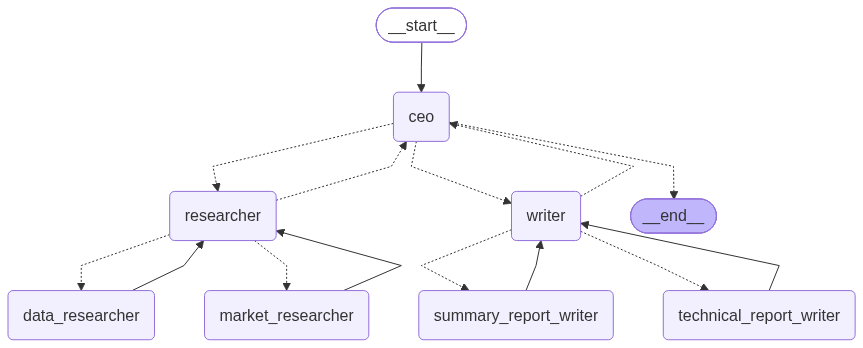

In [20]:
graph = crete_router_graph()
graph

In [21]:
response = graph.invoke({"messages": """
Prepare a comprehensive analysis of the current state and future potential of Generative AI in enterprise software development. Analyze the key technologies, architectures, use cases, benefits, limitations, security considerations, adoption trends, and major market players. Based on the research, identify the major opportunities and challenges for organizations planning to adopt Generative AI.
"""
})

researcher
data_researcher
market_researcher
done
content='# Generative AI in Enterprise Software Development – Combined Market & Research Report  \n*Prepared for: Enterprise CIOs, CTOs, and AI Strategy Teams*  \n*Date:\u202fAugust\u202f2026*  \n\n---\n\n## Executive Summary  \n\nGenerative AI (Gen‑AI) has moved from a niche research area to a core capability that is reshaping how enterprises build, test, and maintain software. By 2030, the enterprise‑software‑focused Gen‑AI market is projected to reach **$23\u202fB** (Gartner) with a CAGR of **28\u202f%** (IDC, 2024‑2027).  \n\nKey drivers:  \n\n| Driver | Impact | Evidence |\n|--------|--------|----------|\n| **Mature LLMs & cloud MaaS** | Rapid experimentation & scaling | Azure OpenAI, Google Vertex AI, Amazon Bedrock |\n| **Low‑code / no‑code AI** | Democratization of app dev | Power Apps AI Builder, Salesforce Einstein GPT |\n| **AI‑augmented DevOps** | Faster release cycles, reduced QA effort | GitHub Actions + Copilot, AWS CodeG

Failed to send compressed multipart ingest: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. ConnectionError(MaxRetryError('HTTPSConnectionPool(host=\'api.smith.langchain.com\', port=443): Max retries exceeded with url: /runs/multipart (Caused by NameResolutionError("HTTPSConnection(host=\'api.smith.langchain.com\', port=443): Failed to resolve \'api.smith.langchain.com\' ([Errno 11001] getaddrinfo failed)"))'))
Content-Length: 24258
API Key: lsv2_********************************************30trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04dec-41ab-74c2-a2be-740bae7068e5; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04dec-41aa-7162-9ebf-4a5b3cb86fb1; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04ded-0226-7a31-b82b-0f48654a1b17; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04ded-0227-7bc0-bf66-9f9dfd4a764c; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04ded-0227-7bc0-bf66

technical_report at agent # Generative AI in Enterprise Software Development  
*Technical Analysis (August 2026)*  

---

## 1. Executive Overview  

Generative AI (Gen‑AI) has transitioned from experimental research to a **core development capability** that reshapes how enterprises write, test, and maintain software. Key facts derived from the combined research report are:

| Metric | Value | Source |
|--------|-------|--------|
| Enterprise‑focused Gen‑AI market (2023) | **$4.4 B** | IDC |
| Projected market (2030) | *
Hiii technical_data_writer
has_technical_report True


Failed to send compressed multipart ingest: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. ConnectionError(MaxRetryError('HTTPSConnectionPool(host=\'api.smith.langchain.com\', port=443): Max retries exceeded with url: /runs/multipart (Caused by NameResolutionError("HTTPSConnection(host=\'api.smith.langchain.com\', port=443): Failed to resolve \'api.smith.langchain.com\' ([Errno 11001] getaddrinfo failed)"))'))
Content-Length: 23662
API Key: lsv2_********************************************30trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04ded-17ee-74a3-ab05-143a911e13e9; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04ded-17ee-74a3-ab05-142d184ff218; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04ded-d451-7640-8197-75fb917eb2be; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04ded-d452-7411-8a67-c176331b889e; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04ded-d452-7411-8a67

technical_report at agent # Generative AI in Enterprise Software Development  
**A Technical Analysis (August 2026)**  

---

## Executive Summary  
Generative AI (Gen‑AI) has transitioned from an experimental research area to a core capability in enterprise software engineering. By 2030, the Gen‑AI market focused on enterprise software is projected to reach **$23 B** (Gartner) with a CAGR of **28 %** (IDC 2024‑2027). Adoption is already widespread: **70 %** of global enterprises plan to deploy Gen‑AI in software develop
Hiii summary_writer
has_technical_report True


Failed to send compressed multipart ingest: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. ConnectionError(MaxRetryError('HTTPSConnectionPool(host=\'api.smith.langchain.com\', port=443): Max retries exceeded with url: /runs/multipart (Caused by NameResolutionError("HTTPSConnection(host=\'api.smith.langchain.com\', port=443): Failed to resolve \'api.smith.langchain.com\' ([Errno 11001] getaddrinfo failed)"))'))
Content-Length: 23798
API Key: lsv2_********************************************30trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04ded-dd8d-7350-a0e4-3f6c7915e94b; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04ded-dd8c-73c1-93f5-513e8798ea3c; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04dee-af77-7032-87af-3361c721cb8a; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04dee-af78-79c0-b763-455b69353246; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04dee-af79-7ab0-a5c4

Hiii done
has_technical_report True


Failed to send compressed multipart ingest: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. ConnectionError(MaxRetryError('HTTPSConnectionPool(host=\'api.smith.langchain.com\', port=443): Max retries exceeded with url: /runs/multipart (Caused by NameResolutionError("HTTPSConnection(host=\'api.smith.langchain.com\', port=443): Failed to resolve \'api.smith.langchain.com\' ([Errno 11001] getaddrinfo failed)"))'))
Content-Length: 21933
API Key: lsv2_********************************************30trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04dee-c65d-7223-8f14-72c271b09fc0; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04dee-c65d-7223-8f14-72b0e3c5f46a; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04def-25a8-7093-9b77-857f4c136c64; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04def-25a9-7b20-bcb6-cae9d6618893; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04def-25a9-7b20-bcb6

content='# Generative AI in Enterprise Software Development  \n**A Technical Analysis (August\u202f2026)**  \n\n---\n\n## Table of Contents  \n\n| # | Section | Page |\n|---|---------|------|\n| 1 | Executive Summary | 1 |\n| 2 | Market Landscape | 2 |\n| 3 | Core Technologies & Architectures | 3 |\n| 4 | Use‑Cases in Enterprise Software Development | 5 |\n| 5 | Benefits & Productivity Gains | 6 |\n| 6 | Limitations & Risks | 7 |\n| 7 | Security & Compliance Considerations | 8 |\n| 8 | Major Market Players & Offerings | 9 |\n| 9 | Opportunities & Challenges for Adopters | 10 |\n| 10 | Emerging Technologies & Future Directions | 12 |\n| 11 | Conclusion | 13 |\n| A | Executive‑Summary Insight Table | 14 |\n\n> **NOTE** – All figures are sourced from Gartner, IDC, NIST, and vendor‑specific studies published up to August\u202f2026.  \n\n---\n\n## 1. Executive Summary  \n\nGenerative AI (Gen‑AI) has evolved from a research curiosity into a *core capability* that is reshaping the enterprise 

In [ ]:
response['final_report']

'# Generative AI in Enterprise Software Development  \n**A Technical Analysis (August\u202f2026)**  \n\n---\n\n## Table of Contents  \n\n| # | Section | Page |\n|---|---------|------|\n| 1 | Executive Summary | 1 |\n| 2 | Market Landscape | 2 |\n| 3 | Core Technologies & Architectures | 3 |\n| 4 | Use‑Cases in Enterprise Software Development | 5 |\n| 5 | Benefits & Productivity Gains | 6 |\n| 6 | Limitations & Risks | 7 |\n| 7 | Security & Compliance Considerations | 8 |\n| 8 | Major Market Players & Offerings | 9 |\n| 9 | Opportunities & Challenges for Adopters | 10 |\n| 10 | Emerging Technologies & Future Directions | 12 |\n| 11 | Conclusion | 13 |\n| A | Executive‑Summary Insight Table | 14 |\n\n> **NOTE** – All figures are sourced from Gartner, IDC, NIST, and vendor‑specific studies published up to August\u202f2026.  \n\n---\n\n## 1. Executive Summary  \n\nGenerative AI (Gen‑AI) has evolved from a research curiosity into a *core capability* that is reshaping the enterprise software

Failed to send compressed multipart ingest: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. ConnectionError(MaxRetryError('HTTPSConnectionPool(host=\'api.smith.langchain.com\', port=443): Max retries exceeded with url: /runs/multipart (Caused by NameResolutionError("HTTPSConnection(host=\'api.smith.langchain.com\', port=443): Failed to resolve \'api.smith.langchain.com\' ([Errno 11001] getaddrinfo failed)"))'))
Content-Length: 23208
API Key: lsv2_********************************************30trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04def-2c73-7e93-a15f-3e0052899bd6; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04def-2c72-7f53-91bf-a1fbfefa3ced; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04df0-2d5e-7253-ab6a-a27504881e7a; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04df0-2d5e-7253-ab6a-a27504881e7a; trace=01a04de8-3350-7a42-9478-3d6c3aafe1ec,id=01a04def-25a8-7093-9b77